In [2]:
# ============================================================
# 00 — CONNECT GOOGLE DRIVE / PROJECT
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ============================================================
# PROJECT PATH
# ============================================================

from pathlib import Path
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FitnessML_Master"
)

print(f"Project directory: {PROJECT_DIR}")
print(f"Exists: {PROJECT_DIR.exists()}")

Project directory: /content/drive/MyDrive/FitnessML_Master
Exists: True


In [7]:
# ============================================================
# ADD PROJECT TO PYTHON PATH
# ============================================================

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project added to Python path.")

Project added to Python path.


In [8]:
# ============================================================
# 02 — FITBIT EDA & TEMPORAL ANALYSIS
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import config_fitbit as config

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

RAW_DIR = Path(config.RAW_DATA_DIR)

print("=" * 70)
print("FITBIT EDA & TEMPORAL ANALYSIS")
print("=" * 70)

print(f"Data directory: {RAW_DIR}")

FITBIT EDA & TEMPORAL ANALYSIS
Data directory: /content/drive/MyDrive/FitnessML_Master/data/raw/fitbit


In [13]:
# ============================================================
# LOAD DAILY DATA
# ============================================================

daily_activity = pd.read_csv(
    RAW_DIR / "dailyActivity_merged.csv"
)

sleep_day = pd.read_csv(
    RAW_DIR / "sleepDay_merged.csv"
)

weight_log = pd.read_csv(
    RAW_DIR / "weightLogInfo_merged.csv"
)

daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"]
)

sleep_day["SleepDay"] = pd.to_datetime(
    sleep_day["SleepDay"]
)

weight_log["Date"] = pd.to_datetime(
    weight_log["Date"]
)

daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"],
    format="%m/%d/%Y"
)

sleep_day["SleepDay"] = pd.to_datetime(
    sleep_day["SleepDay"],
    format="%m/%d/%Y %I:%M:%S %p"
)

weight_log["Date"] = pd.to_datetime(
    weight_log["Date"],
    format="%m/%d/%Y %I:%M:%S %p"
)

print("=" * 70)
print("DAILY DATA LOADED")
print("=" * 70)

print(f"Activity : {daily_activity.shape}")
print(f"Sleep    : {sleep_day.shape}")
print(f"Weight   : {weight_log.shape}")

DAILY DATA LOADED
Activity : (940, 15)
Sleep    : (413, 5)
Weight   : (67, 8)


/tmp/ipykernel_1208/1303583072.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_day["SleepDay"] = pd.to_datetime(
/tmp/ipykernel_1208/1303583072.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight_log["Date"] = pd.to_datetime(


In [10]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("=" * 70)
print("DAILY ACTIVITY — DESCRIPTIVE STATISTICS")
print("=" * 70)

display(
    daily_activity.describe(
        include="all"
    ).T
)

DAILY ACTIVITY — DESCRIPTIVE STATISTICS


,count,mean,min,25%,50%,75%,max,std
Id,940.0,4855407369.332978,1503960366.0,2320127002.0,4445114986.0,6962181067.0,8877689391.0,2424805475.657955
ActivityDate,940,2016-04-26 06:53:37.021276672,2016-04-12 00:00:00,2016-04-19 00:00:00,2016-04-26 00:00:00,2016-05-04 00:00:00,2016-05-12 00:00:00,NaN
TotalSteps,940.0,7637.910638,0.0,3789.75,7405.5,10727.0,36019.0,5087.150742
TotalDistance,940.0,5.489702,0.0,2.62,5.245,7.7125,28.030001,3.924606
TrackerDistance,940.0,5.475351,0.0,2.62,5.245,7.71,28.030001,3.907276
LoggedActivitiesDistance,940.0,0.108171,0.0,0.0,0.0,0.0,4.942142,0.619897
VeryActiveDistance,940.0,1.502681,0.0,0.0,0.21,2.0525,21.92,2.658941
ModeratelyActiveDistance,940.0,0.567543,0.0,0.0,0.24,0.8,6.48,0.88358
LightActiveDistance,940.0,3.340819,0.0,1.945,3.365,4.7825,10.71,2.040655
SedentaryActiveDistance,940.0,0.001606,0.0,0.0,0.0,0.0,0.11,0.007346


In [11]:
# ============================================================
# NUMERIC FEATURES
# ============================================================

activity_numeric = daily_activity.select_dtypes(
    include=np.number
).drop(
    columns=["Id"],
    errors="ignore"
)

display(activity_numeric.describe().T)

,count,mean,std,min,25%,50%,75%,max
TotalSteps,940.0,7637.910638,5087.150742,0.0,3789.750,7405.500,10727.0000,36019.000000
TotalDistance,940.0,5.489702,3.924606,0.0,2.620,5.245,7.7125,28.030001
TrackerDistance,940.0,5.475351,3.907276,0.0,2.620,5.245,7.7100,28.030001
LoggedActivitiesDistance,940.0,0.108171,0.619897,0.0,0.000,0.000,0.0000,4.942142
VeryActiveDistance,940.0,1.502681,2.658941,0.0,0.000,0.210,2.0525,21.920000
ModeratelyActiveDistance,940.0,0.567543,0.883580,0.0,0.000,0.240,0.8000,6.480000
LightActiveDistance,940.0,3.340819,2.040655,0.0,1.945,3.365,4.7825,10.710000
SedentaryActiveDistance,940.0,0.001606,0.007346,0.0,0.000,0.000,0.0000,0.110000
VeryActiveMinutes,940.0,21.164894,32.844803,0.0,0.000,4.000,32.0000,210.000000
FairlyActiveMinutes,940.0,13.564894,19.987404,0.0,0.000,6.000,19.0000,143.000000


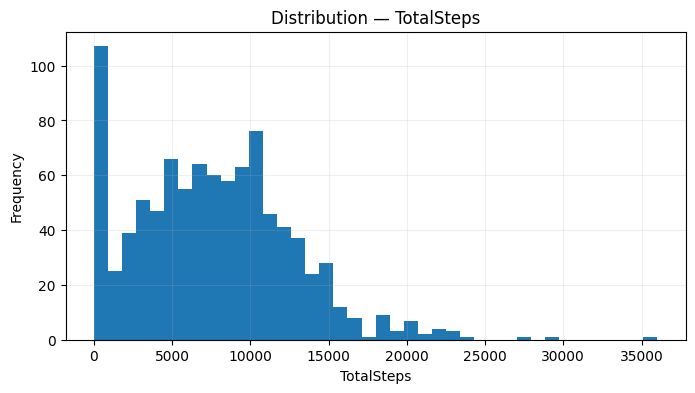

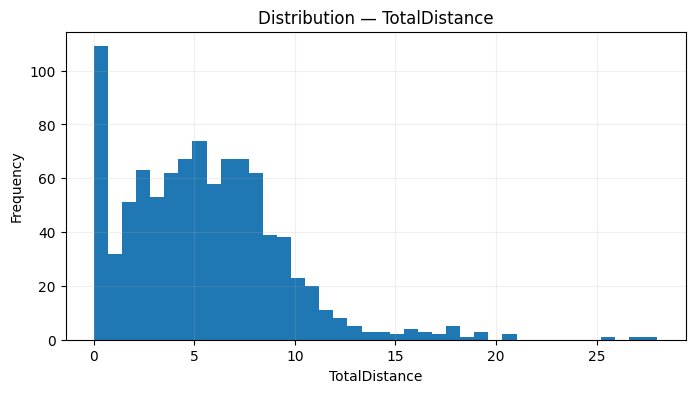

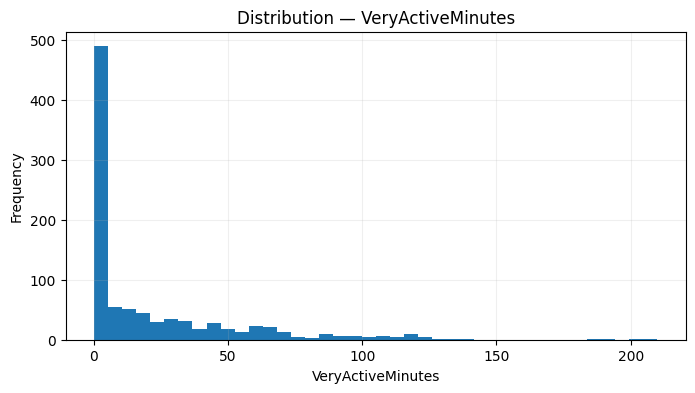

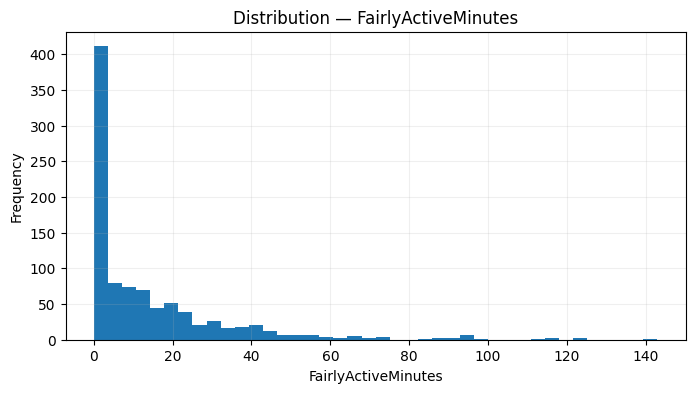

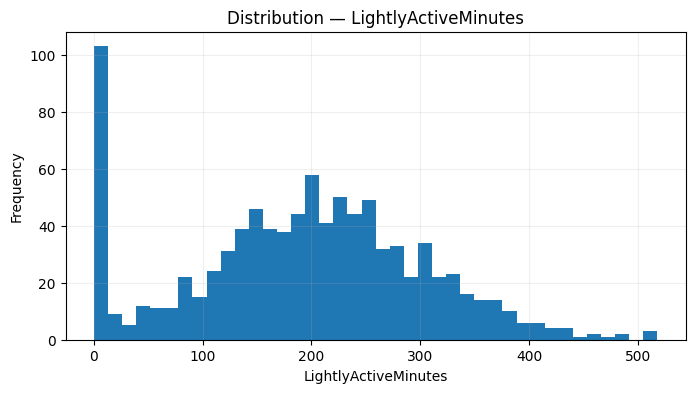

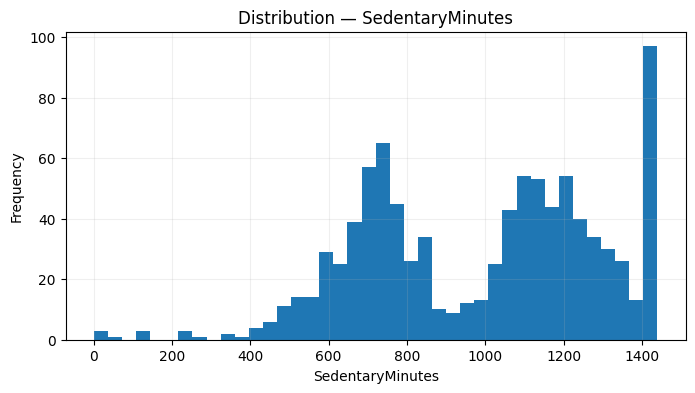

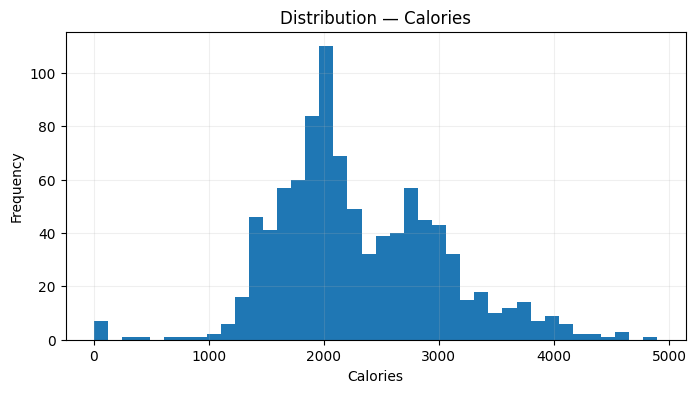

In [14]:
# ============================================================
# DISTRIBUTIONS OF MAIN DAILY FEATURES
# ============================================================

main_features = [
    "TotalSteps",
    "TotalDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories"
]

for feature in main_features:

    if feature not in daily_activity.columns:
        continue

    plt.figure(figsize=(8, 4))

    plt.hist(
        daily_activity[feature].dropna(),
        bins=40
    )

    plt.title(f"Distribution — {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.2)
    plt.show()

In [15]:
# ============================================================
# BETWEEN-USER VARIABILITY
# ============================================================

user_means = (
    daily_activity
    .groupby("Id")[main_features]
    .mean()
)

print("=" * 70)
print("BETWEEN-USER VARIABILITY")
print("=" * 70)

display(user_means.describe().T)

BETWEEN-USER VARIABILITY


,count,mean,std,min,25%,50%,75%,max
TotalSteps,33.0,7519.272678,3576.340125,916.129032,5566.870968,7282.966667,9519.666667,16040.032258
TotalDistance,33.0,5.398953,2.772293,0.634516,3.454839,5.295333,6.913548,13.212903
VeryActiveMinutes,33.0,20.308769,23.803214,0.096774,3.580645,10.387097,23.419355,87.333333
FairlyActiveMinutes,33.0,13.260240,12.108217,0.258065,4.034483,12.322581,19.354839,61.266667
LightlyActiveMinutes,33.0,191.521291,75.689747,38.580645,143.838710,206.193548,245.806452,327.900000
SedentaryMinutes,33.0,999.151475,227.678526,662.322581,766.419355,1077.550000,1206.612903,1317.419355
Calories,33.0,2282.443660,562.761632,1483.354839,1916.967742,2131.769231,2599.620690,3436.580645


In [16]:
# ============================================================
# WITHIN-USER VARIABILITY
# ============================================================

user_stds = (
    daily_activity
    .groupby("Id")[main_features]
    .std()
)

print("=" * 70)
print("WITHIN-USER VARIABILITY")
print("=" * 70)

display(user_stds.describe().T)

WITHIN-USER VARIABILITY


,count,mean,std,min,25%,50%,75%,max
TotalSteps,33.0,3460.460643,1230.428217,1205.269064,2712.836854,3369.790624,3941.753387,6177.048612
TotalDistance,33.0,2.562009,1.117082,0.833966,1.848067,2.418186,3.115145,6.154033
VeryActiveMinutes,33.0,17.677560,13.707959,0.499462,5.643533,16.255185,24.405975,61.754985
FairlyActiveMinutes,33.0,13.437061,8.898409,1.436842,6.985546,12.428981,17.688534,41.038194
LightlyActiveMinutes,33.0,77.235169,30.641517,26.441577,57.012826,67.290623,93.204163,176.178196
SedentaryMinutes,33.0,187.810309,86.157315,64.578299,111.491916,186.645970,236.531573,398.720998
Calories,33.0,416.371714,165.200317,158.311820,291.992363,415.606335,544.859097,792.747796


In [17]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

correlation = activity_numeric.corr()

print("=" * 70)
print("DAILY ACTIVITY CORRELATION MATRIX")
print("=" * 70)

display(
    correlation.round(3)
)

DAILY ACTIVITY CORRELATION MATRIX


,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
TotalSteps,1.000,0.985,0.985,0.182,0.740,0.507,0.692,0.071,0.667,0.499,0.570,-0.327,0.592
TotalDistance,0.985,1.000,1.000,0.188,0.795,0.471,0.662,0.082,0.681,0.463,0.516,-0.288,0.645
TrackerDistance,0.985,1.000,1.000,0.163,0.794,0.470,0.661,0.075,0.681,0.463,0.515,-0.289,0.645
LoggedActivitiesDistance,0.182,0.188,0.163,1.000,0.151,0.077,0.138,0.155,0.234,0.054,0.102,-0.047,0.208
VeryActiveDistance,0.740,0.795,0.794,0.151,1.000,0.193,0.158,0.046,0.827,0.212,0.060,-0.062,0.492
ModeratelyActiveDistance,0.507,0.471,0.470,0.077,0.193,1.000,0.238,0.006,0.225,0.947,0.162,-0.221,0.217
LightActiveDistance,0.692,0.662,0.661,0.138,0.158,0.238,1.000,0.100,0.155,0.220,0.886,-0.414,0.467
SedentaryActiveDistance,0.071,0.082,0.075,0.155,0.046,0.006,0.100,1.000,0.008,-0.022,0.124,0.035,0.044
VeryActiveMinutes,0.667,0.681,0.681,0.234,0.827,0.225,0.155,0.008,1.000,0.312,0.052,-0.165,0.616
FairlyActiveMinutes,0.499,0.463,0.463,0.054,0.212,0.947,0.220,-0.022,0.312,1.000,0.149,-0.237,0.298


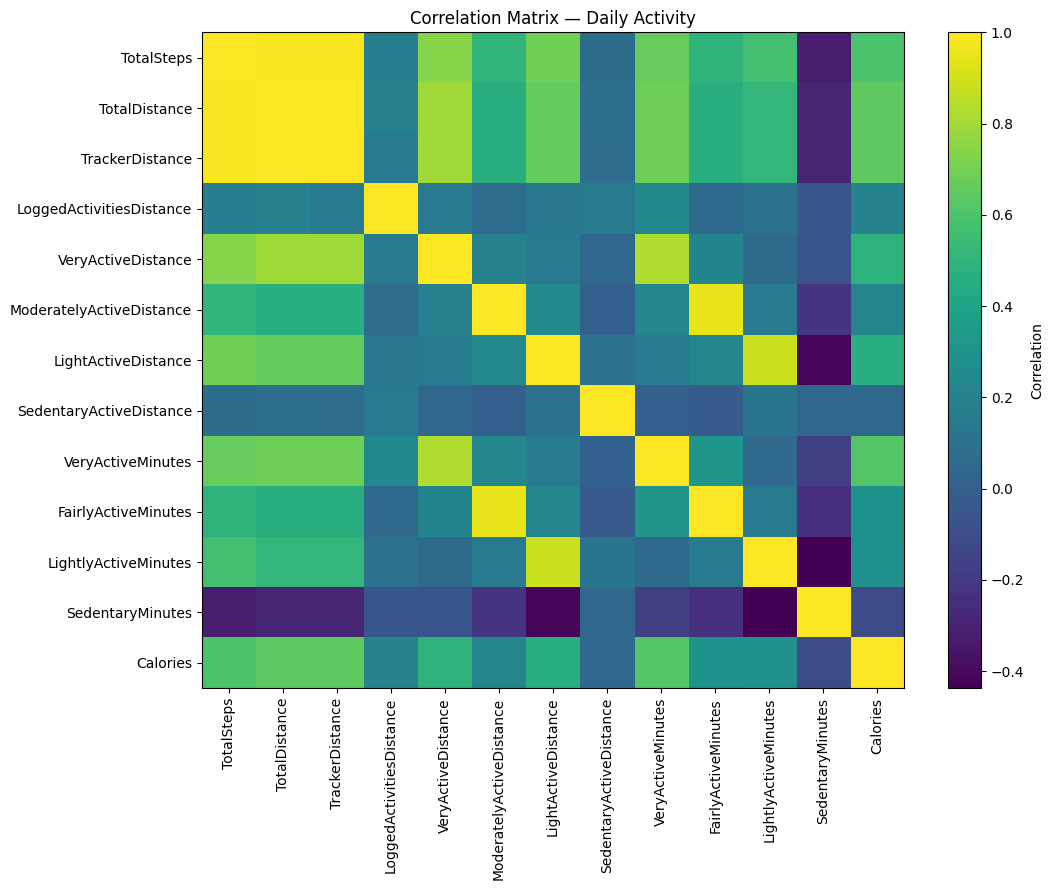

In [18]:
plt.figure(figsize=(11, 9))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix — Daily Activity")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# TEMPORAL AUTOCORRELATION
# ============================================================

print("=" * 70)
print("TEMPORAL AUTOCORRELATION")
print("=" * 70)

temporal_features = [
    "TotalSteps",
    "TotalDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories"
]

lags = [1, 2, 3, 7]

autocorr_results = []

for feature in temporal_features:

    for lag in lags:

        values = []

        for user_id, group in daily_activity.groupby("Id"):

            group = group.sort_values("ActivityDate")

            if len(group) <= lag:
                continue

            corr = group[feature].autocorr(lag=lag)

            if pd.notna(corr):
                values.append(corr)

        if values:

            autocorr_results.append({
                "feature": feature,
                "lag": lag,
                "users": len(values),
                "mean": np.mean(values),
                "median": np.median(values),
                "std": np.std(values),
                "min": np.min(values),
                "max": np.max(values)
            })

autocorr_df = pd.DataFrame(autocorr_results)

display(
    autocorr_df.round(3)
)

TEMPORAL AUTOCORRELATION


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,lag,users,mean,median,std,min,max
0,TotalSteps,1,33,0.110,0.096,0.262,-0.275,0.683
1,TotalSteps,2,33,0.047,0.020,0.240,-0.439,1.000
2,TotalSteps,3,32,0.046,0.010,0.195,-0.297,0.420
3,TotalSteps,7,32,0.051,0.015,0.282,-0.421,0.684
4,TotalDistance,1,33,0.106,0.096,0.267,-0.399,0.683
5,TotalDistance,2,33,0.046,0.028,0.241,-0.439,1.000
6,TotalDistance,3,32,0.039,0.010,0.191,-0.299,0.421
7,TotalDistance,7,32,0.047,0.000,0.280,-0.440,0.690
8,VeryActiveMinutes,1,31,0.109,0.085,0.236,-0.340,0.660
9,VeryActiveMinutes,2,31,-0.059,-0.073,0.185,-0.450,0.297


In [20]:
# ============================================================
# AUTOCORRELATION MATRIX
# ============================================================

autocorr_matrix = autocorr_df.pivot(
    index="feature",
    columns="lag",
    values="mean"
)

print("=" * 70)
print("MEAN USER-LEVEL AUTOCORRELATION")
print("=" * 70)

display(
    autocorr_matrix.round(3)
)

MEAN USER-LEVEL AUTOCORRELATION


lag,1,2,3,7
feature,,,,
Calories,0.158,-0.031,0.042,0.028
FairlyActiveMinutes,0.063,-0.033,0.027,0.053
LightlyActiveMinutes,0.143,0.015,0.036,0.054
SedentaryMinutes,0.127,-0.011,-0.005,-0.021
TotalDistance,0.106,0.046,0.039,0.047
TotalSteps,0.110,0.047,0.046,0.051
VeryActiveMinutes,0.109,-0.059,-0.059,0.018


In [21]:
# ============================================================
# SHARE OF USERS WITH POSITIVE AUTOCORRELATION
# ============================================================

positive_autocorr = (
    autocorr_df
    .assign(
        positive_share=lambda x: np.nan
    )
)

for feature in temporal_features:

    for lag in lags:

        user_corrs = []

        for user_id, group in daily_activity.groupby("Id"):

            group = group.sort_values("ActivityDate")

            if len(group) <= lag:
                continue

            corr = group[feature].autocorr(lag=lag)

            if pd.notna(corr):
                user_corrs.append(corr)

        if user_corrs:
            share = np.mean(np.array(user_corrs) > 0)

            positive_autocorr.loc[
                (positive_autocorr["feature"] == feature) &
                (positive_autocorr["lag"] == lag),
                "positive_share"
            ] = share

display(
    positive_autocorr[
        ["feature", "lag", "positive_share"]
    ].round(3)
)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib

,feature,lag,positive_share
0,TotalSteps,1,0.606
1,TotalSteps,2,0.576
2,TotalSteps,3,0.562
3,TotalSteps,7,0.531
4,TotalDistance,1,0.636
5,TotalDistance,2,0.576
6,TotalDistance,3,0.562
7,TotalDistance,7,0.500
8,VeryActiveMinutes,1,0.613
9,VeryActiveMinutes,2,0.323


In [23]:
# ============================================================
# CROSS-LAG CORRELATION
# Previous day feature -> target
# ============================================================

print("=" * 70)
print("CROSS-LAG CORRELATION — PREVIOUS DAY → TARGET")
print("=" * 70)

target_features = [
    "TotalSteps",
    "Calories"
]

predictor_features = [
    "TotalSteps",
    "TotalDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes"
]

cross_lag_results = []

for target_name in target_features:

    for predictor_name in predictor_features:

        user_corrs = []

        for user_id, user_df in daily_activity.groupby("Id"):

            user_df = (
                user_df
                .sort_values("ActivityDate")
                .reset_index(drop=True)
            )

            previous_day = user_df[predictor_name].shift(1)
            target_day = user_df[target_name]

            pair = pd.DataFrame({
                "previous": previous_day,
                "target": target_day
            }).dropna()

            # Need enough observations
            if len(pair) < 3:
                continue

            # Correlation is undefined for constant series
            if pair["previous"].nunique() <= 1:
                continue

            if pair["target"].nunique() <= 1:
                continue

            corr = pair["previous"].corr(pair["target"])

            if pd.notna(corr):
                user_corrs.append(corr)

        if user_corrs:

            cross_lag_results.append({
                "target": target_name,
                "previous_day_feature": predictor_name,
                "users": len(user_corrs),
                "mean": np.mean(user_corrs),
                "median": np.median(user_corrs),
                "std": np.std(user_corrs),
                "min": np.min(user_corrs),
                "max": np.max(user_corrs),
                "positive_share": np.mean(
                    np.array(user_corrs) > 0
                )
            })

cross_lag_df = pd.DataFrame(cross_lag_results)

display(
    cross_lag_df.round(3)
)

CROSS-LAG CORRELATION — PREVIOUS DAY → TARGET


,target,previous_day_feature,users,mean,median,std,min,max,positive_share
0,TotalSteps,TotalSteps,33,0.110,0.096,0.262,-0.275,0.683,0.606
1,TotalSteps,TotalDistance,33,0.108,0.100,0.263,-0.294,0.683,0.636
2,TotalSteps,VeryActiveMinutes,32,0.084,0.075,0.231,-0.423,0.569,0.594
3,TotalSteps,FairlyActiveMinutes,32,0.077,0.057,0.203,-0.348,0.447,0.719
4,TotalSteps,LightlyActiveMinutes,33,0.124,0.077,0.220,-0.208,0.716,0.697
5,TotalSteps,SedentaryMinutes,33,-0.104,-0.080,0.207,-0.719,0.240,0.333
6,Calories,TotalSteps,33,0.121,0.073,0.226,-0.292,0.684,0.727
7,Calories,TotalDistance,33,0.122,0.064,0.225,-0.281,0.683,0.727
8,Calories,VeryActiveMinutes,32,0.092,0.093,0.208,-0.286,0.703,0.656
9,Calories,FairlyActiveMinutes,32,0.035,0.039,0.221,-0.666,0.396,0.562


In [24]:
# ============================================================
# CROSS-LAG SUMMARY
# ============================================================

display(
    cross_lag_df[
        [
            "target",
            "previous_day_feature",
            "mean",
            "median",
            "positive_share"
        ]
    ]
    .sort_values(
        ["target", "mean"],
        ascending=[True, False]
    )
    .round(3)
)

,target,previous_day_feature,mean,median,positive_share
10,Calories,LightlyActiveMinutes,0.123,0.086,0.667
7,Calories,TotalDistance,0.122,0.064,0.727
6,Calories,TotalSteps,0.121,0.073,0.727
8,Calories,VeryActiveMinutes,0.092,0.093,0.656
9,Calories,FairlyActiveMinutes,0.035,0.039,0.562
11,Calories,SedentaryMinutes,-0.102,-0.068,0.364
4,TotalSteps,LightlyActiveMinutes,0.124,0.077,0.697
0,TotalSteps,TotalSteps,0.110,0.096,0.606
1,TotalSteps,TotalDistance,0.108,0.100,0.636
2,TotalSteps,VeryActiveMinutes,0.084,0.075,0.594


In [25]:
# ============================================================
# LAG HISTORY ANALYSIS
# Previous N days -> next-day target
# ============================================================

print("=" * 70)
print("LAG HISTORY ANALYSIS — PREVIOUS DAYS → NEXT-DAY TARGET")
print("=" * 70)

target_name = "Calories"

lag_features = [
    "TotalSteps",
    "TotalDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories"
]

max_lag = 7

lag_results = []

for predictor_name in lag_features:

    for lag in range(1, max_lag + 1):

        user_corrs = []

        for user_id, user_df in daily_activity.groupby("Id"):

            user_df = (
                user_df
                .sort_values("ActivityDate")
                .reset_index(drop=True)
            )

            previous_value = user_df[predictor_name].shift(lag)
            target_value = user_df[target_name]

            pair = pd.DataFrame({
                "previous": previous_value,
                "target": target_value
            }).dropna()

            if len(pair) < 5:
                continue

            if pair["previous"].nunique() <= 1:
                continue

            if pair["target"].nunique() <= 1:
                continue

            corr = pair["previous"].corr(pair["target"])

            if pd.notna(corr):
                user_corrs.append(corr)

        if user_corrs:

            lag_results.append({
                "feature": predictor_name,
                "lag": lag,
                "users": len(user_corrs),
                "mean": np.mean(user_corrs),
                "median": np.median(user_corrs),
                "std": np.std(user_corrs),
                "positive_share": np.mean(
                    np.array(user_corrs) > 0
                )
            })

lag_df = pd.DataFrame(lag_results)

display(
    lag_df.round(3)
)

LAG HISTORY ANALYSIS — PREVIOUS DAYS → NEXT-DAY TARGET


,feature,lag,users,mean,median,std,positive_share
0,TotalSteps,1,32,0.104,0.067,0.206,0.719
1,TotalSteps,2,32,0.001,-0.012,0.194,0.500
2,TotalSteps,3,32,0.049,0.060,0.190,0.594
3,TotalSteps,4,32,0.038,0.040,0.157,0.594
4,TotalSteps,5,32,-0.030,-0.036,0.180,0.438
5,TotalSteps,6,32,0.028,0.028,0.182,0.625
6,TotalSteps,7,32,0.013,-0.028,0.238,0.438
7,TotalDistance,1,32,0.104,0.062,0.205,0.719
8,TotalDistance,2,32,0.001,-0.007,0.193,0.500
9,TotalDistance,3,32,0.045,0.059,0.189,0.594


In [26]:
# ============================================================
# LAG SUMMARY
# ============================================================

lag_summary = lag_df.pivot(
    index="feature",
    columns="lag",
    values="mean"
)

print("=" * 70)
print("MEAN USER-LEVEL CORRELATION BY LAG")
print("=" * 70)

display(
    lag_summary.round(3)
)

MEAN USER-LEVEL CORRELATION BY LAG


lag,1,2,3,4,5,6,7
feature,,,,,,,
Calories,0.140,-0.001,0.042,0.003,-0.044,-0.007,0.028
FairlyActiveMinutes,0.035,-0.008,0.044,0.001,-0.022,0.058,-0.013
LightlyActiveMinutes,0.103,0.017,0.060,0.034,-0.010,-0.012,0.050
SedentaryMinutes,-0.082,-0.054,-0.038,0.023,-0.001,-0.028,-0.028
TotalDistance,0.104,0.001,0.045,0.035,-0.029,0.026,0.014
TotalSteps,0.104,0.001,0.049,0.038,-0.030,0.028,0.013
VeryActiveMinutes,0.092,-0.029,-0.015,-0.015,-0.044,0.039,0.001


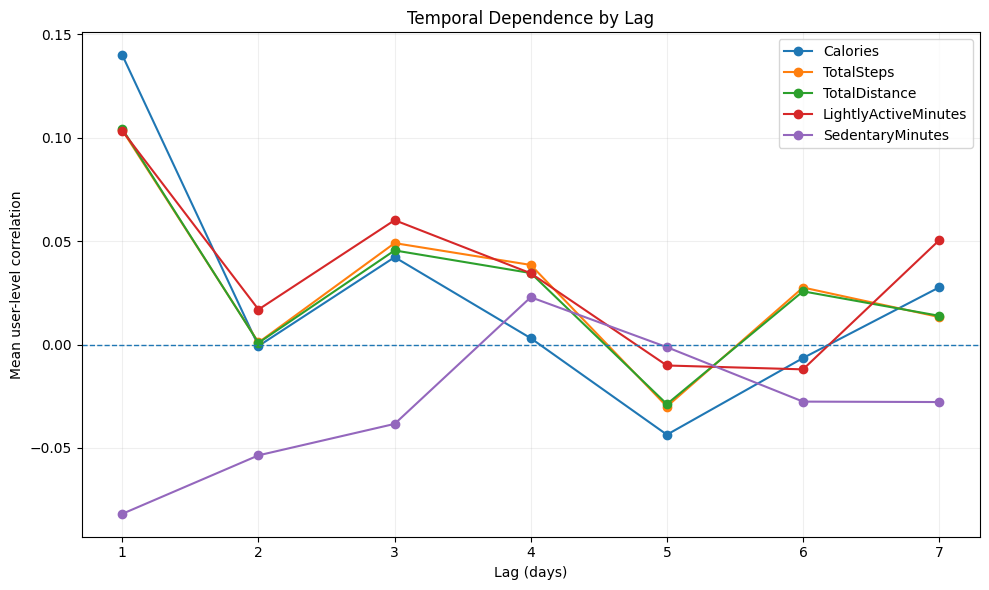

In [27]:
# ============================================================
# LAG CORRELATION — MAIN FEATURES
# ============================================================

plt.figure(figsize=(10, 6))

for feature in [
    "Calories",
    "TotalSteps",
    "TotalDistance",
    "LightlyActiveMinutes",
    "SedentaryMinutes"
]:

    subset = lag_df[
        lag_df["feature"] == feature
    ]

    plt.plot(
        subset["lag"],
        subset["mean"],
        marker="o",
        label=feature
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Lag (days)")
plt.ylabel("Mean user-level correlation")
plt.title("Temporal Dependence by Lag")
plt.xticks(range(1, max_lag + 1))
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# STRONGEST TEMPORAL RELATIONSHIPS
# ============================================================

print("=" * 70)
print("STRONGEST TEMPORAL RELATIONSHIPS")
print("=" * 70)

display(
    lag_df
    .sort_values("mean", ascending=False)
    .head(15)
    .round(3)
)

STRONGEST TEMPORAL RELATIONSHIPS


,feature,lag,users,mean,median,std,positive_share
42,Calories,1,32,0.140,0.147,0.197,0.781
7,TotalDistance,1,32,0.104,0.062,0.205,0.719
0,TotalSteps,1,32,0.104,0.067,0.206,0.719
28,LightlyActiveMinutes,1,32,0.103,0.075,0.197,0.656
14,VeryActiveMinutes,1,32,0.092,0.093,0.208,0.656
30,LightlyActiveMinutes,3,32,0.060,0.064,0.188,0.625
26,FairlyActiveMinutes,6,32,0.058,0.047,0.199,0.656
34,LightlyActiveMinutes,7,32,0.050,0.083,0.205,0.562
2,TotalSteps,3,32,0.049,0.060,0.190,0.594
9,TotalDistance,3,32,0.045,0.059,0.189,0.594
